In [ ]:
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from   sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from   transformers import AutoConfig, AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
import torch
import torch.nn as nn
from   torch.utils.data import Dataset, DataLoader

In [ ]:
# model definition
MODEL_NAME = "beomi/kcbert-base"

# label definition
LABEL_SCHEMA: dict[str, list[str]] = {
    # the direction of flavor. Multi-label selection is supported.
    "taste": [
        "spicy",
        "rich",
        "sweet",
        "salty",
        "unique",
        "complex",
        "no data",
    ],
    # material of a patty. Multi-label selection is unsupported.
    "material": [
        "beef",
        "pork",
        "chicken",
        "etc.",
    ],
    # features of a hamburger. Multi-label selection is supported.
    "feature": [
        "meaty/maillard",
        "gooey cheese",
        "flavorful",
        "signature item",
        "no vegetable",
        "balanced flavor",
        "no feature"
    ],
    # price: price information. Multi-label selection is unsupported.
    "price": [
        "expensive",
        "affordable",
        "cheap",
        "no price data"
    ],
    # revisit: user’s willingness to revisit. Multi-label selection is unsupported.
    "revisit": [
        "willing to revisit",
        "conditional revisit",
        "worthy to try",
        "no willing to revisit"
    ]
}

MULTI_LABEL = {"taste", "feature"}

# loss function definition
criteria = {
    # Multi-label selection is supported -> BCE
    "taste":   nn.BCEWithLogitsLoss(),
    "feature": nn.BCEWithLogitsLoss(),
    # Multi-label selection is unsupported -> Cross Entropy
    "material": nn.CrossEntropyLoss(),
    "price":    nn.CrossEntropyLoss(),
    "revisit":  nn.CrossEntropyLoss(),

}

# Loss weight
LOSS_WEIGHTS = {
    "taste": 1.2,
    "material": 0.8,
    "feature": 1.5,
    "price": 0.8,
    "revisit": 1.2,
}

threshold=[]

In [ ]:
# Review Classifier
class BurgerMultiTaskClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.config = AutoConfig.from_pretrained(MODEL_NAME)
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(self.config.hidden_dropout_prob)


        # make head for each label
        self.heads = nn.ModuleDict({
            name: nn.Linear(self.config.hidden_size, len(labels))
            for name, labels in LABEL_SCHEMA.items()
        })
    
    def forward(self, input_ids, attention_mask = None):
        outputs = self.transformer(input_ids = input_ids, attention_mask = attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled_output)
        
        # each label makes weight for class
        return { name: head(pooled) for name, head in self.heads.items()}

# one time classify
    @torch.no_grad()
    def predict(self, input_ids, attention_mask = None)-> dict[str, list[str]]:
        logits = self.forward(input_ids, attention_mask)
        result = {}
        for name, logit in logits.items():
            if name in MULTI_LABEL:
                # BCE -> sigmoid -> threshold
                probs = torch.sigmoid(logit)
                selected_indices = (probs > threshold[name]).nonzero(as_tuple=True)[1]
                result[name] = [LABEL_SCHEMA[name][i] for i in selected_indices]
            else:
                # CE -> softmax -> argmax
                probs = torch.softmax(logit, dim=-1)
                idx = torch.argmax(probs, dim=-1).item()
                result[name] = [LABEL_SCHEMA[name][idx]]
        return result
    
    def classify(self, review: str) -> dict[str, list[str]]:
        device = next(self.parameters()).device
        encoding = self.tokenizer(
            review,
            max_length=128,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return self.predict(
            encoding["input_ids"].to(device),
            encoding["attention_mask"].to(device),
        )

In [ ]:
# data preprocess class
class BurgerReviewDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_length=120):
        self.reviews = reviews
        self.labels = labels    # {"taste": [...], "material": [...], ...}
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.reviews[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
        }

        # make output for each label
        # multi selection -> multi-hot
        # single selection -> integer index
        for category, label_indices in self.labels[idx].items():
            if category in MULTI_LABEL:
                num_labels = len(LABEL_SCHEMA[category])
                multi_hot = torch.zeros(num_labels)
                multi_hot[label_indices] = 1.0
                item[category] = multi_hot.float()
            else:
                item[category] = torch.tensor(label_indices[0], dtype=torch.long)

        return item

In [ ]:
# model training function definition

# loss data to analyze loss curve
train_losses = []
val_losses   = []
train_losses_label = {name: [] for name in LABEL_SCHEMA}
val_losses_label   = {name: [] for name in LABEL_SCHEMA}

def train(model, train_dataset, val_dataset, num_epochs = 20, batch_size = 8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size = batch_size)

    optimizer = torch.optim.AdamW([
            {"params": model.transformer.parameters(), "lr": 1e-5},
            {"params": model.heads.parameters(),       "lr": 3e-5},
    ], weight_decay = 0.01)

    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps = total_steps // 10,
        num_training_steps = total_steps,
    )

    best_val_loss = float("inf")
    patience = 5 # early stop if no loss reduction for 5 epoch
    no_improve = 0

    for epoch in range(num_epochs):
        ### train
        model.train()
        train_loss = 0.0
        train_loss_label = {name: 0.0 for name in LABEL_SCHEMA}
        for batch in train_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)

            losses_label = {
                name: LOSS_WEIGHTS[name] * criteria[name](
                    logits[name],
                    batch[name].to(device),
                )
                for name in LABEL_SCHEMA
            }
            loss = sum(losses_label.values())

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            for name in LABEL_SCHEMA:
                train_loss_label[name] += losses_label[name].item()
        
        train_losses.append(train_loss / len(train_loader))
        for name in LABEL_SCHEMA:
            train_losses_label[name].append(
                train_loss_label[name] / len(train_loader)
            )

        ### validation
        val_loss, val_loss_label = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        for name in LABEL_SCHEMA:
            val_losses_label[name].append(val_loss_label[name])

        print(f"Epoch {epoch+ 1 }/{num_epochs} | "
              f"train_loss: {train_loss/len(train_loader):.4f} | "
              f"val_loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            torch.save(model.state_dict(), SAVED_MODEL)
            print("  -> best model saved")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

# model evaluate function definition
def evaluate(model, loader, device):
    model.eval()
    # validation loss summation
    total_loss = 0.0
    # validation loss about labels
    total_loss_label = {name: 0.0 for name in LABEL_SCHEMA}

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            loss_label = {
                name: criteria[name](logits[name], batch[name].to(device))
                for name in LABEL_SCHEMA
            }
            total_loss += sum(loss_label.values()).item()
            for name in LABEL_SCHEMA:
                total_loss_label[name] += loss_label[name].item()

    n = len(loader)
    return (
        total_loss / n,
        {name: total_loss_label[name] / n for name in LABEL_SCHEMA}
    )

In [ ]:
# model test function
def test(model, test_dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(SAVED_MODEL))
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_dataset, batch_size=8)

    all_preds  = {name: [] for name in LABEL_SCHEMA}  # prediction
    all_labels = {name: [] for name in LABEL_SCHEMA}  # correct answer

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)

            for name in LABEL_SCHEMA:
                if name in MULTI_LABEL:
                    # BCE -> sigmoid -> threshold
                    probs = torch.sigmoid(logits[name])
                    preds = (probs > threshold[name]).cpu()
                else:
                    # CE -> softmax -> argmax
                    probs = torch.softmax(logits[name], dim=-1)
                    preds = torch.argmax(probs, dim=-1).cpu()
                labels_bat = batch[name].cpu()

                all_preds[name].append(preds)
                all_labels[name].append(labels_bat)

    all_preds  = {name: torch.cat(tensors) for name, tensors in all_preds.items()}
    all_labels = {name: torch.cat(tensors) for name, tensors in all_labels.items()}

    return all_preds, all_labels

In [ ]:
# find best threshold for each label in trained model
def find_best_threshold(model, val_dataset):
    # get prediction rate in val set
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    val_loader = DataLoader(val_dataset, batch_size=8)
    all_probs  = {name: [] for name in MULTI_LABEL}
    all_labels = {name: [] for name in MULTI_LABEL}

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            logits = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
            )
            for name in MULTI_LABEL:
                all_probs[name].append(torch.sigmoid(logits[name]).cpu())
                all_labels[name].append(batch[name].cpu())

    all_probs  = {name: torch.cat(v) for name, v in all_probs.items()}
    all_labels = {name: torch.cat(v) for name, v in all_labels.items()}

    best_thresholds = {}
    for name in MULTI_LABEL:
        best_f1, best_t = 0.0, 0.5
        for t in [i / 100 for i in range(20, 80)]:   # 0.20 ~ 0.79 
            preds = (all_probs[name] > t).numpy()
            f1    = f1_score(all_labels[name].numpy(), preds,
                             average="macro", zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t

        best_thresholds[name] = best_t
        print(f"[{name}] best threshold: {best_t:.2f}  (F1: {best_f1:.4f})")

    return best_thresholds


In [ ]:
# test visualization tool

matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows Korean Font
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac
matplotlib.rcParams['axes.unicode_minus'] = False

def compute_metrics(all_preds, all_labels):
    print("=" * 60)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(20, 12)
    )
    axes = axes.flatten()

    for idx, name in enumerate(LABEL_SCHEMA):
        preds  = all_preds[name].numpy()
        labels = all_labels[name].numpy()
        label_names = LABEL_SCHEMA[name]

        print(f"\n[{name}]")
        if name in MULTI_LABEL: # BCE -> multi-hot
            avg = "macro"
            print(classification_report(
                labels, preds,
                target_names=label_names,
                zero_division=0,
            ))
            # BCE → macro confusion matrix in summation of each label's TP/FP/FN/TN
            cm = np.zeros((2, 2), dtype=int)
            for i in range(len(label_names)):
                cm += confusion_matrix(labels[:, i], preds[:, i], labels=[0, 1])
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=["negative", "positive"]
            )
            title = f"[{name}] 전체 합산\nmacro F1: {f1_score(labels, preds, average='macro', zero_division=0):.3f}"

        else: # CE -> integer index
            avg = "weighted"
            print(classification_report(
                labels, preds,
                target_names=label_names,
                labels=list(range(len(label_names))),
                zero_division=0,
            ))
            # CE → confusion matrix in each class
            cm = confusion_matrix(
                labels, preds,
                labels=list(range(len(label_names)))
            )
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=label_names
            )
            title = f"[{name}]\nweighted F1: {f1_score(labels, preds, average='weighted', zero_division=0):.3f}"

        ax = axes[idx]
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(title, fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

    # hide remaining subplot
    for i in range(len(LABEL_SCHEMA), len(axes)):
        axes[i].axis("off")

    # Total average F1
    all_p = torch.cat([all_preds[n] for n in MULTI_LABEL], dim=1).numpy()
    all_l = torch.cat([all_labels[n] for n in MULTI_LABEL], dim=1).numpy()
    macro_f1 = f1_score(all_l, all_p, average="macro", zero_division=0)
    micro_f1 = f1_score(all_l, all_p, average="micro", zero_division=0)
    print(f"\n전체 Macro F1: {macro_f1:.4f}")
    print(f"전체 Micro F1: {micro_f1:.4f}")

    plt.tight_layout()
    plt.show()


# loss curve visualization tool
# Total loss + label loss

def show_loss_curve():
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    best_epoch = val_losses.index(min(val_losses)) + 1
    best_val   = min(val_losses)

    # 1st subplot: total loss
    axes[0].plot(epochs, train_losses, label="train", marker="o", markersize=3)
    axes[0].plot(epochs, val_losses,   label="val",   marker="o", markersize=3)

    axes[0].axvline(x=best_epoch, color="red", linestyle="--", alpha=0.5, label=f"best epoch {best_epoch}")
    axes[0].annotate(
        f"val_loss: {best_val:.4f}",
        xy=(best_epoch, best_val),
        xytext=(best_epoch + 1, best_val + 0.2),
        arrowprops=dict(arrowstyle="->", color="red"),
        color="red", fontsize=9
    )
    axes[0].set_title("전체 Loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    # other subplot: label loss
    for idx, name in enumerate(LABEL_SCHEMA, start=1):
        ax = axes[idx]
        ax.plot(epochs, train_losses_label[name], label="train", marker="o", markersize=3)
        ax.plot(epochs, val_losses_label[name],   label="val",   marker="o", markersize=3)
        best = val_losses_label[name].index(min(val_losses_label[name])) + 1
        val = min(val_losses_label[name])
        ax.axvline(x=best, color="red", linestyle="--", alpha=0.5, label=f"best epoch {best}")
        ax.annotate(
            f"val_loss: {val:.4f}",
            xy=(best, val),
            xytext=(best + 1, val + 0.2),
            arrowprops=dict(arrowstyle="->", color="red"),
            color="red", fontsize=9
        )

        ax.set_title(f"[{name}] Loss")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# run in colab environment
# put reviews.json, labels.json in google drive "/20201473" directory

# %pip install google.colab
from google.colab import drive
drive.mount("/content/drive")
with open("/content/drive/MyDrive/20201473/reviews.json", "r", encoding = "utf-8") as f:
    reviews_json = json.load(f)
reviews = [item["0"] for item in reviews_json]

with open("/content/drive/MyDrive/20201473/labels.json", "r", encoding = "utf-8") as f:
    labels = json.load(f)

# location of trained model 
SAVED_MODEL = "/content/drive/MyDrive/20201473/best_model.pt"

ModuleNotFoundError: No module named 'google'

In [ ]:
# run in local environment
with open("reviews.json", "r", encoding = "utf-8") as f:
    reviews_json = json.load(f)
reviews = [item["0"] for item in reviews_json]

with open("labels.json", "r", encoding = "utf-8") as f:
    labels = json.load(f)

# location of trained model
SAVED_MODEL = "best_model.pt"

In [ ]:
# data division to 8:1:1
train_reviews = reviews[1:400]
val_reviews   = reviews[401:450]
test_reviews  = reviews[451:500]

train_labels = labels[1:400]
val_labels   = labels[401:450]
test_labels  = labels[451:500]

# prepare tokenizer, model, dataset
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = BurgerMultiTaskClassifier()

train_dataset = BurgerReviewDataset(train_reviews, train_labels, tokenizer)
val_dataset   = BurgerReviewDataset(val_reviews,   val_labels,   tokenizer)
test_dataset  = BurgerReviewDataset(test_reviews,  test_labels,  tokenizer) 


c:\DevelopingFiles\repositories\git\Iburgifier\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
# load trained model
model.load_state_dict(torch.load(SAVED_MODEL))

<All keys matched successfully>

In [ ]:
# model training
train(model, train_dataset, val_dataset)

Epoch 1/20 | train_loss: 5.4261 | val_loss: 3.5777
  -> best model saved
Epoch 2/20 | train_loss: 4.0317 | val_loss: 3.2157
  -> best model saved
Epoch 3/20 | train_loss: 3.6836 | val_loss: 3.0063
  -> best model saved
Epoch 4/20 | train_loss: 3.2832 | val_loss: 2.8342
  -> best model saved
Epoch 5/20 | train_loss: 2.8033 | val_loss: 2.8719
Epoch 6/20 | train_loss: 2.3955 | val_loss: 2.8107
  -> best model saved
Epoch 7/20 | train_loss: 2.0839 | val_loss: 2.7655
  -> best model saved
Epoch 8/20 | train_loss: 1.7466 | val_loss: 2.7071
  -> best model saved
Epoch 9/20 | train_loss: 1.5024 | val_loss: 2.8898
Epoch 10/20 | train_loss: 1.2913 | val_loss: 3.2653
Epoch 11/20 | train_loss: 1.1520 | val_loss: 3.1584
Epoch 12/20 | train_loss: 1.0532 | val_loss: 3.1753
Epoch 13/20 | train_loss: 0.9559 | val_loss: 3.2674
Early stopping at epoch 13


In [ ]:
# should run before test, classify
threshold = find_best_threshold(model, val_dataset)

[taste] best threshold: 0.24  (F1: 0.4013)
[feature] best threshold: 0.24  (F1: 0.3604)



[taste]
              precision    recall  f1-score   support

       spicy       0.50      0.10      0.17        10
        rich       0.00      0.00      0.00         2
       sweet       1.00      0.20      0.33         5
       salty       0.30      0.83      0.44        12
      unique       0.33      0.20      0.25         5
     complex       0.60      0.96      0.74        27
     no data       0.25      0.57      0.35         7

   micro avg       0.44      0.63      0.52        68
   macro avg       0.43      0.41      0.33        68
weighted avg       0.49      0.63      0.48        68
 samples avg       0.46      0.62      0.50        68


[material]
              precision    recall  f1-score   support

        beef       0.63      0.85      0.72        26
        pork       0.00      0.00      0.00         0
     chicken       0.71      0.50      0.59        20
        etc.       0.00      0.00      0.00         3

    accuracy                           0.65        49
  

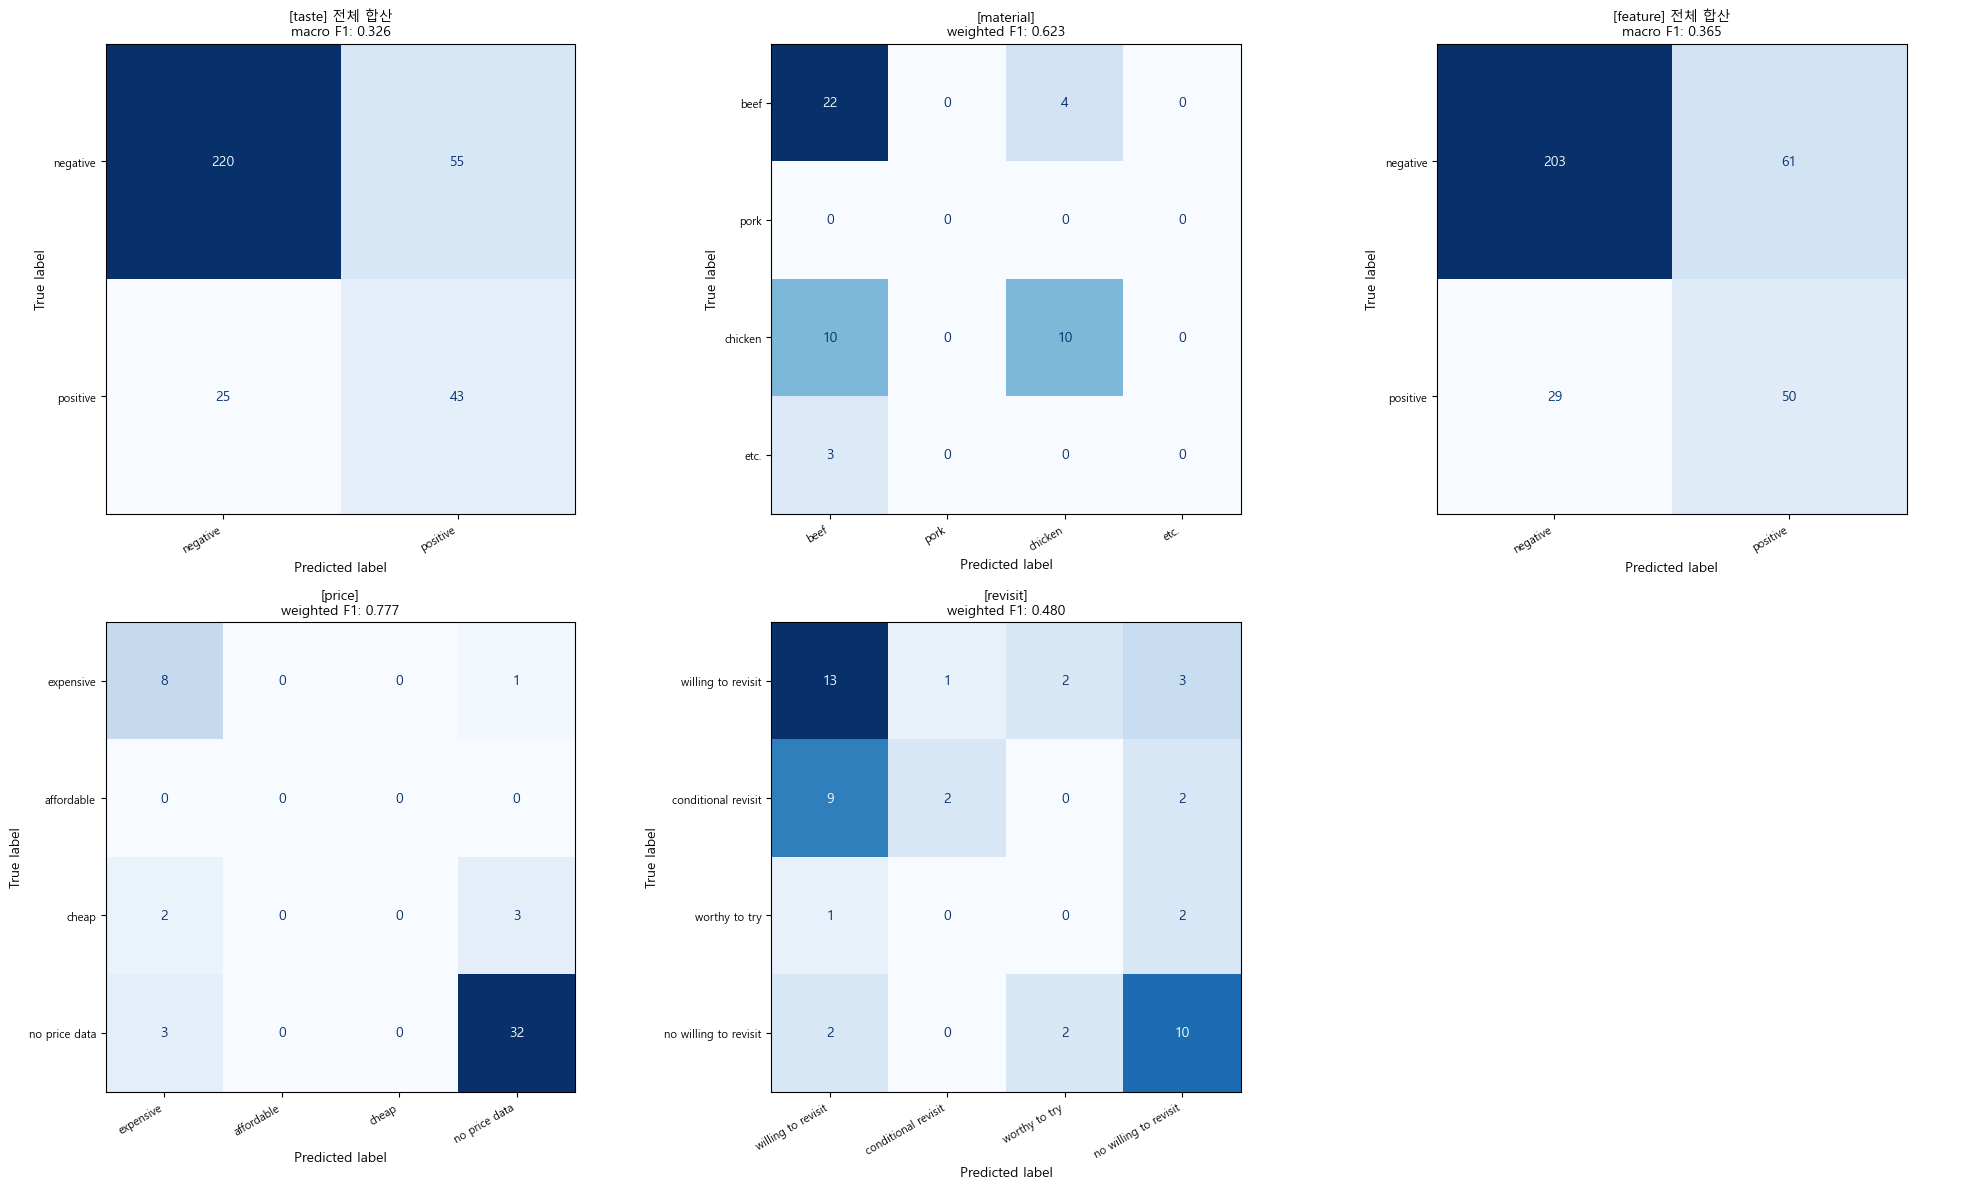

In [ ]:
# model test and print result
all_preds, all_labels = test(model, test_dataset)
compute_metrics(all_preds, all_labels)

In [ ]:
# visualized loss curve
show_loss_curve()

In [ ]:
# classify one time
print(model.classify("더블 쿼터파운드 치즈버거. 육향이랑 치즈향은 기막힘. 근데 비싸서 자주 먹기는 조금 그런듯"))